In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import networkx as nx

try:
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base_dir = os.getcwd()
sys.path.append(os.path.dirname(base_dir))

from data_processing.pyg_graph_generator import *
from data_processing.sample_scoring import *

/opt/anaconda3/envs/firegnn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def plot_venn(set1, set2, label1, label2):
    plt.figure(figsize=(6,4))
    venn2(subsets=(set1, set2), set_labels=(label1, label2))
    plt.title("Overlapping Proteins")
    plt.show()

# Old PPI-KG

In [3]:
ppi_kg = pd.read_csv("../CLEP_repeat/clep_resources/Datasets/ADNI/threshold/data/ppi-kg.edgelist", sep='\t')
ppi_kg

,source,relation,target
0,USP7,decreases,TP53
1,SFN,association,SYNJ2
2,PAK1,association,PIK3CB
3,BIRC6,association,MAP2K1
4,AXIN1,association,SMAD7
...,...,...,...
209814,XRCC5,increases,ATRIP
209815,ZFYVE16,regulates,SMAD4
209816,ZNF655,increases,SP1
209817,ZNF655,increases,FADD


In [44]:
ppi_kg.isna().sum()

source      48
relation     0
target      50
dtype: int64

In [4]:
cleaned_ppi_df = ppi_kg.dropna()
cleaned_ppi_df

,source,relation,target
0,USP7,decreases,TP53
1,SFN,association,SYNJ2
2,PAK1,association,PIK3CB
3,BIRC6,association,MAP2K1
4,AXIN1,association,SMAD7
...,...,...,...
209814,XRCC5,increases,ATRIP
209815,ZFYVE16,regulates,SMAD4
209816,ZNF655,increases,SP1
209817,ZNF655,increases,FADD


In [40]:
old_ppi_kg = nx.MultiDiGraph()
for i, row in ppi_kg.iterrows():
    src = row['source']
    dst = row['target']
    rel = row['relation']
    
    # 1. Robustly check for NaN (catches both float nan and string 'nan')
    if pd.isna(src) or str(src).lower() == 'nan' or pd.isna(dst) or str(dst).lower() == 'nan':
        continue # Skip this broken triple entirely
        
    # 2. Add nodes safely
    if src not in old_ppi_kg:
        old_ppi_kg.add_node(src, label='Protein')
    if dst not in old_ppi_kg:
        old_ppi_kg.add_node(dst, label='Protein')
        
    # 3. Add edge safely
    old_ppi_kg.add_edge(src, dst, relation=rel)

# save graph
with open("../datasets/base_kgs/old_ppi_kg.pkl",'wb') as f:
    pickle.dump(old_ppi_kg, f)
print(f"Save graph of {old_ppi_kg.number_of_nodes()} nodes and {old_ppi_kg.number_of_edges()} edges")

Save graph of 8910 nodes and 209730 edges


In [46]:
PPI_Proteins = set(cleaned_ppi_df['source'].unique()) | set(cleaned_ppi_df['target'].unique())
len(PPI_Proteins)

8910

### ADNI data in CLEP

In [6]:
sample_scoring = pd.read_csv("../CLEP_repeat/clep_resources/Datasets/ADNI/kge_model/results/sample_scoring.tsv", sep='\t', index_col=0)
sample_scoring

,HIST1H3G,HIST1H3G.1,HIST1H3G.2,TNFAIP8L1,OTOP2,C17ORF78,LINC01098,SAMD7,ARRDC5,C1ORF173,...,H3F3AP4.2,RNA18S5,RNA45S5,RNA18S5.1,RNA45S5.1,RNA18S5.2,RNA45S5.2,RNA28S5,RNA45S5.3,label
116_S_1249,0,0,0,-1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
037_S_4410,0,0,0,-1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
006_S_4153,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
116_S_1232,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
099_S_4205,-1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
009_S_2381,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
053_S_4557,0,0,0,0,0,0,-1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
073_S_4300,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,1
041_S_4014,0,0,0,0,0,0,0,-1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
scoring_2 = pd.read_csv("../CLEP_repeat/clep_resources/Datasets/ADNI/threshold/results/1/sample_scoring.tsv", sep='\t', index_col=0)
scoring_2

,HIST1H3G,HIST1H3G.1,HIST1H3G.2,TNFAIP8L1,OTOP2,C17ORF78,LINC01098,SAMD7,ARRDC5,C1ORF173,...,H3F3AP4.2,RNA18S5,RNA45S5,RNA18S5.1,RNA45S5.1,RNA18S5.2,RNA45S5.2,RNA28S5,RNA45S5.3,label
116_S_1249,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
037_S_4410,0,0,0,-1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
006_S_4153,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
116_S_1232,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
099_S_4205,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
009_S_2381,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
053_S_4557,0,0,0,0,0,0,-1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
073_S_4300,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,1
041_S_4014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
GE_clep = set(sample_scoring.columns)
len(GE_clep)

49945

In [8]:
sample_label_map = sample_scoring['label'].to_dict()
sample_label_map

{'116_S_1249': 0,
 '037_S_4410': 0,
 '006_S_4153': 1,
 '116_S_1232': 0,
 '099_S_4205': 1,
 '007_S_4467': 1,
 '128_S_0205': 1,
 '003_S_2374': 1,
 '036_S_4491': 0,
 '098_S_4059': 1,
 '031_S_2018': 1,
 '002_S_4654': 1,
 '019_S_4285': 1,
 '141_S_4426': 1,
 '067_S_4072': 1,
 '037_S_4308': 0,
 '041_S_4200': 0,
 '128_S_0200': 1,
 '129_S_4220': 1,
 '018_S_4313': 0,
 '067_S_0257': 0,
 '029_S_1218': 1,
 '141_S_4053': 1,
 '136_S_4408': 1,
 '021_S_2142': 1,
 '114_S_4404': 1,
 '116_S_4167': 1,
 '116_S_4209': 1,
 '073_S_4360': 1,
 '072_S_4539': 1,
 '007_S_2394': 1,
 '128_S_1407': 1,
 '109_S_2200': 1,
 '057_S_1269': 1,
 '022_S_1097': 1,
 '010_S_0420': 0,
 '072_S_2083': 1,
 '014_S_4615': 1,
 '073_S_4259': 1,
 '002_S_1268': 1,
 '024_S_0985': 0,
 '073_S_4382': 0,
 '127_S_0684': 0,
 '067_S_4310': 1,
 '035_S_0156': 0,
 '041_S_4427': 0,
 '127_S_0622': 0,
 '129_S_4396': 0,
 '019_S_4477': 1,
 '002_S_1261': 0,
 '041_S_4271': 1,
 '003_S_1122': 1,
 '941_S_2060': 1,
 '012_S_4094': 1,
 '129_S_4287': 1,
 '135_S_43

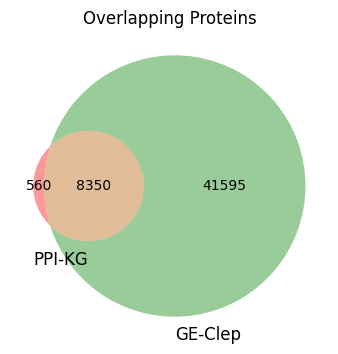

In [47]:
plot_venn(PPI_Proteins, GE_clep, 'PPI-KG', "GE-Clep")

### ADNI I am Using

In [5]:
exp_path = "../data/ADNI/cleaned_gene_expression_data.csv"
exp_df = pd.read_csv(exp_path, index_col=0)
exp_df.T

gene,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AACSP1,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
116_S_1249,3.651,2.2865,3.039,2.3395,2.783,2.0565,2.081,7.043,3.30950,2.202,...,3.77150,4.0365,2.988,4.353000,4.739500,1.9045,5.31750,9.2190,7.3010,5.7490
037_S_4410,3.183,2.1230,3.543,2.2085,2.383,2.3490,1.733,6.773,3.27625,2.317,...,4.17300,4.4415,3.471,4.520667,4.702333,1.9265,5.38800,8.3785,6.7580,6.0935
006_S_4153,3.278,2.3545,3.528,2.1745,2.593,2.5260,1.841,6.910,3.20875,2.540,...,3.91275,4.6210,2.967,4.230667,4.545333,2.2315,5.62800,9.1085,7.3365,5.2615
116_S_1232,3.371,2.3725,3.835,2.1545,2.570,2.4720,2.249,7.209,3.24950,2.559,...,3.73800,4.4435,3.207,4.050667,4.562500,2.0545,5.46300,9.3210,7.1685,4.7340
099_S_4205,3.358,2.3865,3.392,2.1720,2.660,2.2965,1.893,6.920,3.15425,2.347,...,3.94600,4.5215,3.611,4.639667,4.890667,2.0405,5.64750,9.0300,7.2025,5.4575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
009_S_2381,3.302,2.5075,3.524,2.2525,2.876,2.8380,2.089,6.805,3.09150,2.650,...,3.50150,4.4685,2.770,3.962333,4.472167,1.9320,5.44275,9.2900,6.7035,4.7915
053_S_4557,3.403,2.3090,3.515,2.3225,3.106,2.7715,2.102,7.265,3.27575,2.603,...,3.58325,4.1555,3.081,4.125667,4.609833,1.9445,5.14000,9.8090,7.2810,4.7055
073_S_4300,3.530,2.4155,3.651,2.0760,2.707,2.3280,2.092,7.375,3.26950,2.557,...,3.63450,4.5165,3.051,4.070333,4.733500,2.0795,5.38775,9.5215,6.9825,5.0785
041_S_4014,3.532,2.4545,3.609,2.3495,3.081,2.8230,2.024,7.257,3.11425,2.497,...,3.68525,4.0480,3.304,3.976333,4.091000,2.0075,5.05725,9.5810,6.6865,3.8660


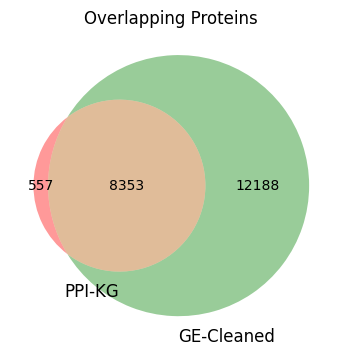

In [49]:
plot_venn(PPI_Proteins, set(exp_df.columns), 'PPI-KG', "GE-Cleaned")

In [26]:
common_cleaned_ppi = PPI_Proteins & set(exp_df.T.columns)
common_raw_ppi = PPI_Proteins & GE_clep
difference_prs = common_cleaned_ppi - common_raw_ppi
difference_prs

{'CACNG4', 'KLRC2', 'ZNF316'}

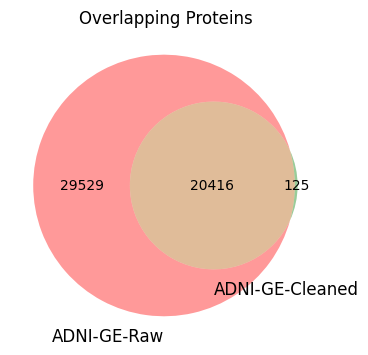

In [50]:
plot_venn(GE_clep, set(exp_df.columns), 'ADNI-GE-Raw', 'ADNI-GE-Cleaned')

In [71]:
adni_raw = pd.read_csv("../data/ADNI/adni_raw_data.csv", sep=None, engine='python',index_col=0)
adni_raw

,11715100_at,11715101_s_at,11715102_x_at,11715103_x_at,11715104_s_at,11715105_at,11715106_x_at,11715107_s_at,11715108_x_at,11715109_at,...,AFFX-r2-TagIN-3_at,AFFX-r2-TagIN-5_at,AFFX-r2-TagIN-M_at,AFFX-r2-TagJ-3_at,AFFX-r2-TagJ-5_at,AFFX-r2-TagO-3_at,AFFX-r2-TagO-5_at,AFFX-r2-TagQ-3_at,AFFX-r2-TagQ-5_at,Label
116_S_1249,2.237,2.624,1.873,2.920,2.147,2.268,2.432,4.600,2.771,2.931,...,2.624,2.010,2.906,2.463,2.050,2.060,1.858,2.028,2.162,0
037_S_4410,2.294,2.416,1.884,2.668,2.156,2.130,2.270,4.547,2.363,2.548,...,2.820,1.726,2.465,2.260,1.933,1.717,2.208,2.058,1.882,0
006_S_4153,2.140,2.322,1.999,3.634,2.516,1.957,2.333,4.442,2.544,2.814,...,2.455,1.840,2.681,2.251,1.985,1.770,2.184,2.007,2.134,1
116_S_1232,2.062,2.500,1.851,3.632,2.283,2.347,2.258,4.608,2.233,3.156,...,2.599,1.837,2.713,2.158,1.916,1.878,2.163,2.185,2.099,0
099_S_4205,2.040,2.395,2.080,3.278,2.251,2.154,2.334,4.536,2.546,2.864,...,2.544,1.909,2.548,2.266,2.077,1.838,2.085,1.941,1.883,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
009_S_2381,2.382,2.277,2.107,3.819,2.588,2.201,2.531,4.455,2.335,2.949,...,2.937,1.964,2.662,2.478,2.017,1.886,2.371,1.997,1.996,1
053_S_4557,2.497,2.466,2.137,3.541,2.256,2.205,2.737,4.725,2.078,2.863,...,2.585,1.997,2.732,2.181,1.885,1.742,2.177,2.176,2.151,1
073_S_4300,2.309,2.607,2.075,3.496,2.098,2.161,2.439,4.981,2.394,2.775,...,2.464,1.924,2.613,2.269,1.807,1.781,2.110,1.875,1.915,1
041_S_4014,2.302,2.569,2.147,4.037,2.376,2.130,2.585,5.005,2.396,2.491,...,2.695,2.108,2.661,2.383,2.188,1.740,2.501,2.070,2.151,0


# Network Generation result compariosn

In [6]:
scoring_path = "../CLEP_repeat/clep_resources/Datasets/ADNI/threshold/results/1/sample_scoring.tsv"
kg_disease_path = "../datasets/base_kgs/old_ppi_kg.pkl"
kg_health_path = "../data/KG/healthy_aging_reversed_remove_noncausal.pkl"

In [8]:
# 1. Load expression df, smaple scoring df, KG

if exp_df.shape[0] > exp_df.shape[1]:
    exp_df = exp_df.transpose()

data = pd.read_csv(scoring_path, sep=r'[,\t\s]+', engine='python',index_col=0)
kg_disease = load_graph(kg_disease_path)
kg_control = load_graph(kg_health_path)

# clean exp_df before K-NN
# drop genes with no variation
exp_df = exp_df.loc[:, exp_df.std() > 0]
# Using median is usually safer for gene expression
exp_df = exp_df.fillna(exp_df.median())
# normalize safely
min_val = exp_df.min()
max_val = exp_df.max()
exp_norm = (exp_df - min_val) / (max_val - min_val + 1e-9)
# final fill-na
exp_norm = exp_norm.fillna(0)

# 2. Generate PatientNetwork
png = PatientNetworkGenerator(kg_disease=kg_disease,
                                kg_healthy=kg_control)

Loaded graph from ../datasets/base_kgs/old_ppi_kg.pkl: 8910 nodes, 209730 edges
Loaded graph from ../data/KG/healthy_aging_reversed_remove_noncausal.pkl: 4161 nodes, 13775 edges


In [62]:
def get_symbol_mapping(graph):
        """
        Universal helper function to create {gene_symbol: [kg_nodes]} mapping 
        across ad_kg, control_kg, ppi_kg, and prime_kg.
        """
        mapping = defaultdict(list)
        if graph is None: 
            return dict(mapping)
        
        for node, attr in graph.nodes(data=True):
            # Ensure node is a string and skip empty/complex modifications
            if not isinstance(node, str) or any(x in node for x in ['frag(', 'var(', 'pmod(', 'loc(']):
                continue
                
            symbol = None
            
            # Case 1: BEL Namespace syntax (ad_kg & control_kg) -> p(HGNC:"...") or p(UniProtKB:"...")
            if node.startswith('p(') and node.endswith(')'):
                if 'HGNC' in node:
                    symbol = png.gene_symbol_extractor(node, png.pattern_hgnc)
                elif 'UniProtKB' in node:
                    symbol = png.gene_symbol_extractor(node, png.pattern_uniprotkb)
                else:
                    # Fallback for unexpected namespaces inside p(...) like p(FIXME:"...")
                    match = re.search(r'["\']([^"\']+)["\']', node)
                    if match:
                        symbol = match.group(1)
                    #continue

            # Case 2: handle (ppi_kg) -> AL1A1_HUMAN
            elif '_' in node and any(suffix in node for suffix in ['_HUMAN']):
                if 'UniProtKB' not in node and 'HGNC' not in node:
                    symbol = png.gene_symbol_extractor(node, png.pattern_dash)

            else:
                # Case 3: handle Gene/Protein symbols in PrimeKg
                clean_node = node.strip().upper()
                if attr.get('label') and attr.get('label') in 'Gene/Protein':
                    symbol = clean_node

            # Append to our list mapping if a valid symbol was resolved
            if symbol:
                symbol_upper = symbol.upper()
                mapping[symbol_upper].append(node)
                
        return dict(mapping)

In [63]:
def generate(
            data: pd.DataFrame, 
            exp_df: pd.DataFrame, 
            base_graph:str='disease') -> Tuple[nx.MultiGraph, pd.DataFrame]:
    """
    Connects samples to KG protein nodes using base_graph.
    """
    patient_labels = data['label'].to_dict()
    scores = data.drop(columns=['label'])
    
    # 1. Force base_graph to MultiDiGraph and copy
    if base_graph == 'disease':
        png.base_graph = png.kg_disease
    else:
        png.base_graph = png.kg_healthy
    
    png.relation_map = {1: f'up_reg', -1: f'down_reg'}

    overlay_graph = nx.MultiDiGraph(png.base_graph).copy()
    
    symbol_to_kg_node = get_symbol_mapping(overlay_graph)
    common_proteins = [s for s in scores.columns if s in symbol_to_kg_node]
    print("common proteins: \n", common_proteins)
    
    sparse_data = scores[common_proteins].stack()
    radicals = sparse_data[sparse_data != 0]
    print('radicals:\n',radicals)

    summary_df = pd.DataFrame(0, index=data.index, columns=['pos_edges', 'neg_edges'])

    summary_df['linked_nodes'] = [[] for _ in range(len(summary_df))] # Initialize with empty lists
    summary_df['label'] = data['label'].to_list()

    # add patient nodes to overlay graph
    overlay_graph = add_patient_attrs(G=overlay_graph,
                                        features_df=exp_df,
                                        labels_series=data['label'],
                                        )
    # add edges between patient and protein
    for key, val in tqdm(radicals.items(), total=len(radicals), desc="Linking Samples"):
        if not (isinstance(key, tuple) and len(key) == 2):
        # unexpected index shape — skip or handle explicitly
            continue
        patient, symbol = key

        for protein_node in symbol_to_kg_node[symbol]:
            rel = png.relation_map.get(int(val))
            
            if not overlay_graph.has_node(patient):
                overlay_graph.add_node(patient, label=patient_labels[patient], type='Patient')

            weight_value = float(exp_df.loc[patient, symbol])
            
            # Use relation as the 'key' for MultiDiGraph edges
            overlay_graph.add_edge(patient, protein_node, relation=rel, weight=weight_value, label=patient_labels[patient])
            overlay_graph.add_edge(protein_node, patient, relation=f'rev_{rel}', weight=weight_value,label=patient_labels[patient])
            
            col = 'pos_edges' if int(val) == 1 else 'neg_edges'
            summary_df.at[patient, col] += 1
            summary_df.at[patient,'linked_nodes'].append(protein_node)

    return overlay_graph, summary_df

## Using Clep sample_scoring.csv, threshold=1

In [73]:
network_clep, summary_clep = generate(data=data,
                                        exp_df=exp_norm,
                                        base_graph='disease')

common proteins: 
 ['RAB3D', 'CACNG8', 'ZNF600', 'OR8U9', 'IFNA10', 'OR9Q2', 'ZNF675', 'KRTAP6-1', 'HNRNPCL1', 'DEPDC5', 'OR2A14', 'RPL38', 'PRB1', 'ZNF680', 'MARK4', 'GRK7', 'UGT2B28', 'MOGAT2', 'MAGI3', 'SLC51B', 'PARD6A', 'RPL36', 'UCN', 'RPL9', 'ZNF184', 'IGLL1', 'CHST7', 'TAS2R30', 'IFNA5', 'MTNR1A', 'UTS2R', 'FIG4', 'PKD1L3', 'UGT2B11', 'TPM2', 'SSX1', 'PGAM4', 'KRT17', 'ASIP', 'CCKAR', 'AGRP', 'CLDN3', 'ST8SIA1', 'CCL27', 'KRT33A', 'FXN', 'SH2D2A', 'NT5C1A', 'PLCB3', 'HOXA10', 'MLXIPL', 'FOXC2', 'LHB', 'HLA-C', 'CYP2C19', 'MAGEA1', 'TTN', 'ZNF735', 'OR6P1', 'GSTP1', 'EBI3', 'HBB', 'COX7C', 'COL1A1', 'COL1A2', 'RPS21', 'CST3', 'TIMP1', 'ATP6V0E1', 'A2M', 'SERPING1', 'NDUFA4', 'UBA1', 'MDH1', 'TRIM28', 'CALR', 'RPS11', 'COX4I1', 'TG', 'LAPTM4B', 'PLD3', 'TOMM7', 'REG1A', 'CDKN1A', 'FKBP1A', 'MTCH1', 'C3', 'CD81', 'APEX1', 'SLC25A5', 'ILF2', 'COL6A1', 'PSMB4', 'PRDX2', 'EPAS1', 'COL3A1', 'DDB1', 'SKP1', 'BCAP31', 'FLNA', 'AKR1B1', 'RBBP7', 'PDIA6', 'TIMP3', 'CPB1', 'DNAJB1', 'TALDO

Linking Samples: 100%|██████████| 129684/129684 [00:25<00:00, 4999.72it/s]


In [74]:
summary_clep

,pos_edges,neg_edges,linked_nodes,label
116_S_1249,90,125,"[SLC51B, COL1A1, TIMP3, RPLP1, RGS2, PLAT, PXD...",0
037_S_4410,185,177,"[OR2A14, ZNF184, AGRP, ST8SIA1, FXN, PLCB3, YW...",0
006_S_4153,70,26,"[MARK4, SMOC2, LAMC1, PIGR, BACE2, ID3, ACIN1,...",1
116_S_1232,44,31,"[COL6A1, ACIN1, NUDT2, APLP1, TEAD3, FBN1, INS...",0
099_S_4205,37,48,"[COL1A1, MBTPS1, FGFR1, PFDN5, XPO1, MYO1D, EI...",1
...,...,...,...,...
009_S_2381,77,69,"[HBB, RPS11, DNAJB1, RPL10, SST, PRL, MRPL16, ...",1
053_S_4557,49,26,"[TPM3, EXOSC5, GREM1, PNLIPRP2, URM1, MGLL, C1...",1
073_S_4300,32,51,"[COL1A1, MT1E, KRAS, HSD11B2, UBE2Q1, PTH, MLY...",1
041_S_4014,268,129,"[MARK4, KRT33A, NT5C1A, MLXIPL, DHCR24, IDH2, ...",0


## Using my sample_scoring.csv, threshold=1

In [64]:
network, summary = generate(data=data,
                                        exp_df=exp_norm,
                                        base_graph='disease')

common proteins: 
 ['A2M', 'A3GALT2', 'A4GALT', 'AAAS', 'AACS', 'AADAT', 'AANAT', 'AARS2', 'AASDHPPT', 'AASS', 'ABAT', 'ABCA1', 'ABCA10', 'ABCA12', 'ABCA13', 'ABCA2', 'ABCA3', 'ABCA4', 'ABCA5', 'ABCA6', 'ABCA7', 'ABCA8', 'ABCA9', 'ABCB1', 'ABCB10', 'ABCB11', 'ABCB4', 'ABCB5', 'ABCB6', 'ABCB7', 'ABCB8', 'ABCB9', 'ABCC1', 'ABCC10', 'ABCC11', 'ABCC12', 'ABCC2', 'ABCC3', 'ABCC4', 'ABCC5', 'ABCC6', 'ABCC8', 'ABCC9', 'ABCD1', 'ABCD2', 'ABCD3', 'ABCD4', 'ABCF2', 'ABCF3', 'ABCG1', 'ABCG2', 'ABCG4', 'ABCG5', 'ABCG8', 'ABHD14A-ACY1', 'ABHD5', 'ABHD6', 'ABI1', 'ABI2', 'ABI3', 'ABL1', 'ABL2', 'ABLIM1', 'ABLIM2', 'ABLIM3', 'ABO', 'ACAA1', 'ACAA2', 'ACACA', 'ACACB', 'ACAD8', 'ACADL', 'ACADM', 'ACADS', 'ACADSB', 'ACADVL', 'ACAP1', 'ACAP2', 'ACAP3', 'ACAT1', 'ACAT2', 'ACE', 'ACE2', 'ACER1', 'ACER2', 'ACER3', 'ACHE', 'ACIN1', 'ACKR3', 'ACKR4', 'ACLY', 'ACMSD', 'ACO1', 'ACO2', 'ACOT1', 'ACOT12', 'ACOT2', 'ACOT4', 'ACOT7', 'ACOT8', 'ACOX1', 'ACOX2', 'ACOX3', 'ACP1', 'ACP2', 'ACP5', 'ACR', 'ACSBG1', 'ACSB

Linking Samples: 100%|██████████| 128409/128409 [00:31<00:00, 4109.10it/s]


In [65]:
summary

,pos_edges,neg_edges,linked_nodes,label
116_S_1249,87,107,"[A4GALT, ACOT12, ADAMTS20, ADORA1, ALDH1L2, AL...",0
037_S_4410,272,299,"[ABCA7, ABCB9, ABCC11, ACADS, ACAP3, ACE, ACER...",0
006_S_4153,80,23,"[ABCA6, ABCA9, ABCB4, ACADM, ANGPTL1, APBB2, A...",1
116_S_1232,38,18,"[ACOT4, ADIPOQ, AGL, AKR1D1, ATP6V1G2, CNTF, C...",0
099_S_4205,33,51,"[ADCYAP1, ALG9, AMOTL1, ANK2, ANTXR1, ARHGEF18...",1
...,...,...,...,...
009_S_2381,82,49,"[ACO1, ADRA2A, ALDH6A1, APOE, ARMS2, ASCL1, AT...",1
053_S_4557,45,18,"[ACMSD, ACTA2, AGTR1, CAMK1G, CCR9, CELA3B, CL...",1
073_S_4300,23,65,"[ACSM3, AQP2, ARHGEF26, ATXN3L, CAMK2B, CAPN13...",1
041_S_4014,269,103,"[AASDHPPT, ABCB6, ABCF2, ACOT8, ACTA1, ADNP, A...",0


In [9]:
from CLEP_repeat.embedding.network_generator import do_graph_gen

graph_clep, summary_clep, linked_genes = do_graph_gen(data=data,
                                                      network_gen_method='interaction_network',
                                                      kg_data=ppi_kg,
                                                      summary=True)

The number of connected components in the graph is greater than 1. There are 130 connected components of size, [8766, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] respectively.
Adding patients to the network: 100%|██████████| 744/744 [02:38<00:00,  4.70it/s]
116_S_1249-MED24 triple is being discarded due to conflicting data
116_S_1249-AP1S3 triple is being discarded due to conflicting data
116_S_1249-PPIH triple is being discarded due to conflicting data
037_S_4410-SLC44A5 triple is being discarded due to conflicting data
037_S_4410-UTP14C triple is being discarded due to conflicting data
037_S_4410-ZNF658 triple is being discarded due to conflicting

In [10]:
summary_clep

,positive_relation,negative_relation,linked_genes,linked_nodes,label
116_S_1249,190,340,0,"[SLC51B, COL1A1, COL6A1, COL3A1, TIMP3, RPLP1,...",0
037_S_4410,388,480,0,"[OR2A14, ZNF184, AGRP, ST8SIA1, FXN, PLCB3, ML...",0
006_S_4153,133,55,0,"[MARK4, COL6A1, SMOC2, LAMC1, PIGR, BACE2, TRA...",1
116_S_1232,115,64,0,"[COL6A1, DDX17, MYO1C, ACIN1, NUDT2, APLP1, ML...",0
099_S_4205,81,138,0,"[COL1A1, MBTPS1, FGFR1, PFDN5, XPO1, MYO1D, EI...",1
...,...,...,...,...,...
009_S_2381,232,144,0,"[HBB, RPS11, DNAJB1, RPL10, SST, THY1, DAG1, P...",1
053_S_4557,118,67,0,"[TPM3, CYP19A1, EXOSC5, GREM1, PNLIPRP2, URM1,...",1
073_S_4300,76,151,0,"[COL1A1, TFRC, LAPTM4A, RHEB, MT1E, CDH1, YAP1...",1
041_S_4014,534,320,0,"[MARK4, DEPDC5, KRT33A, NT5C1A, MLXIPL, COL1A1...",0


In [11]:
graph_df: pd.DataFrame = nx.to_pandas_edgelist(graph_clep)

graph_df['relation'] = graph_df['relation'].fillna('no_change', inplace=True)

graph_df = graph_df[['source', 'target', 'relation', 'label']]
graph_df

/var/folders/ft/2nftg5q91n5dhpf5dtts4gkm0000gn/T/ipykernel_64199/904211384.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  graph_df['relation'] = graph_df['relation'].fillna('no_change', inplace=True)


,source,target,relation,label
0,USP7,TP53,decreases,NaN
1,USP7,MCM5,association,NaN
2,USP7,CRKL,association,NaN
3,USP7,BMI1,association,NaN
4,USP7,KIF3A,association,NaN
...,...,...,...,...
502309,007_S_0101,P2RY11,up_reg,1.0
502310,007_S_0101,COMMD3-BMI1,up_reg,1.0
502311,007_S_0101,BMI1,up_reg,1.0
502312,007_S_0101,DUSP8,up_reg,1.0


In [24]:
graph_df[graph_df['source']=='116_S_1249']

,source,target,relation,label
209779,116_S_1249,SLC51B,down_reg,0.0
209780,116_S_1249,COL1A1,down_reg,0.0
209781,116_S_1249,COL6A1,down_reg,0.0
209782,116_S_1249,COL3A1,down_reg,0.0
209783,116_S_1249,TIMP3,up_reg,0.0
...,...,...,...,...
210301,116_S_1249,ZNF98,down_reg,0.0
210302,116_S_1249,ZNF492,down_reg,0.0
210303,116_S_1249,ALG9,down_reg,0.0
210304,116_S_1249,CSNK1A1,down_reg,0.0


In [41]:
train_df = pd.read_csv("../CLEP_repeat/clep_resources/Datasets/ADNI/threshold/results/1/train.edgelist", sep=r'[,\t\s]+', engine='python', header=None)
test_df = pd.read_csv("../CLEP_repeat/clep_resources/Datasets/ADNI/threshold/results/1/test.edgelist", sep=r'[,\t\s]+', engine='python', header=None)
val_df = pd.read_csv("../CLEP_repeat/clep_resources/Datasets/ADNI/threshold/results/1.5/validation.edgelist", sep=r'[,\t\s]+', engine='python', header=None)
weighted_edgelist = pd.read_csv("../CLEP_repeat/clep_resources/Datasets/ADNI/threshold/results/1.5/validation.edgelist", sep=r'[,\t\s]+', engine='python',header=None)
graph_df_clep = pd.concat([train_df, test_df, val_df, weighted_edgelist],axis=0)
graph_df_clep.columns = ['source','relation','target']
graph_df_clep

,source,relation,target
0,HIF1A,association,MCM7
1,SNRPA1,association,SNRPG
2,SMAD3,association,UCHL5
3,SIRT2,association,GSTT2B
4,PDIA6,association,CDK2
...,...,...,...
39721,137_S_4299,up_reg,FADS2
39722,068_S_0473,up_reg,PKN1
39723,128_S_4653,up_reg,ZNF248
39724,012_S_1212,up_reg,TTC37


In [42]:
graph_df_clep[graph_df_clep['source']=='116_S_1249']

,source,relation,target
128520,116_S_1249,down_reg,IL31
129900,116_S_1249,down_reg,MYH6
130076,116_S_1249,down_reg,SLC44A5
130153,116_S_1249,down_reg,IL13
130180,116_S_1249,down_reg,SLC1A7
...,...,...,...
37972,116_S_1249,up_reg,INPP5B
38813,116_S_1249,up_reg,LILRB2
38916,116_S_1249,up_reg,ALDH1L1
38948,116_S_1249,up_reg,EFNB3


In [43]:
patient_target_clep = graph_df_clep[graph_df_clep['source']=='116_S_1249']['target'].to_list()
patient_target = graph_df[graph_df['source']=='116_S_1249']['target'].to_list()

In [44]:
len(set(patient_target_clep))

205

In [45]:
len(set(patient_target))

527